# March ML Mania 2026 — Advanced Model

**Strategy:** Use every available data source to build a rich feature set, then stack LightGBM + XGBoost + Logistic Regression into a blended ensemble with isotonic calibration. Optimize directly for Brier score via Optuna.

**New vs baseline:**
- Coach features (tenure, historical tournament win rate)
- Conference tier features (Power 6 vs mid-major)
- Conference tournament performance (momentum, wins before NCAA tourney)
- Enhanced Massey: top-25 count, top-10 count, rank spread
- Pythagorean win expectation (better calibrated than raw win%)
- Neutral-site record from game cities
- LightGBM added to ensemble
- Stacked meta-learner (LR on OOF predictions)
- Isotonic calibration
- Separate M/W models — women's gets subset without Massey

## 1 · Imports & Config

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import brier_score_loss, log_loss
from xgboost import XGBClassifier
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# Reuse core pipeline utilities
from pipeline import (
    build_elo_ratings,
    build_matchup_dataset,
    season_walkforward_splits,
    MODEL_FEATURE_COLS,
)
from features import get_summarized_season, build_massey_features
from clustering import add_team_clusters

DATA   = '/Users/loganheydt/Desktop/Data/GitHub/Kaggle_competitions/March_Machine_Learning_Mania_2026/data'
OUT    = '../submissions'
CUTOFF = 2003   # drop seasons before this (incomplete detailed stats)
RUN_TUNING = True   # flip to True for Optuna search (adds ~15 min)

/Users/loganheydt/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 · Load All Data

In [2]:
# ── Core game data ────────────────────────────────────────────────────────────
m_regular = pd.read_csv(f'{DATA}/MRegularSeasonDetailedResults.csv')
m_tourney  = pd.read_csv(f'{DATA}/MNCAATourneyDetailedResults.csv')
m_seeds    = pd.read_csv(f'{DATA}/MNCAATourneySeeds.csv')
w_regular  = pd.read_csv(f'{DATA}/WRegularSeasonDetailedResults.csv')
w_tourney  = pd.read_csv(f'{DATA}/WNCAATourneyDetailedResults.csv')
w_seeds    = pd.read_csv(f'{DATA}/WNCAATourneySeeds.csv')

# ── Supplemental data ─────────────────────────────────────────────────────────
massey        = pd.read_csv(f'{DATA}/MMasseyOrdinals.csv')
coaches       = pd.read_csv(f'{DATA}/MTeamCoaches.csv')
m_conferences = pd.read_csv(f'{DATA}/MTeamConferences.csv')
w_conferences = pd.read_csv(f'{DATA}/WTeamConferences.csv')
m_conf_tourney= pd.read_csv(f'{DATA}/MConferenceTourneyGames.csv')
w_conf_tourney= pd.read_csv(f'{DATA}/WConferenceTourneyGames.csv')
game_cities   = pd.read_csv(f'{DATA}/MGameCities.csv')
w_game_cities = pd.read_csv(f'{DATA}/WGameCities.csv')

# ── Submission ─────────────────────────────────────────────────────────────────
sample_sub = pd.read_csv(f'{DATA}/SampleSubmissionStage2.csv')

# Apply season cutoff
for df in [m_regular, m_tourney, m_seeds, w_regular, w_tourney, w_seeds]:
    df.drop(df[df['Season'] < CUTOFF].index, inplace=True)

print(f"Men's   regular : {len(m_regular):,}  tourney : {len(m_tourney):,}")
print(f"Women's regular : {len(w_regular):,}  tourney : {len(w_tourney):,}")
print(f"Coaches         : {len(coaches):,}")
print(f"Massey rows     : {len(massey):,}  systems : {massey['SystemName'].nunique()}")
print(f"Game cities M   : {len(game_cities):,}  W : {len(w_game_cities):,}")
print(f"Submission rows : {len(sample_sub):,}")

Men's   regular : 124,529  tourney : 1,449
Women's regular : 87,187  tourney : 961
Coaches         : 13,900
Massey rows     : 5,865,001  systems : 197
Game cities M   : 92,438  W : 89,035
Submission rows : 132,133


## 3 · Advanced Feature Engineering

Builds features not present in the baseline: coach quality, conference strength, conference tournament momentum, enhanced Massey, neutral-site record, and pythagorean expectation.

In [3]:
def build_coach_features(coaches_df, tourney_df, season_cutoff=CUTOFF):
    """
    Per team per season:
      - coach_seasons_with_team  : continuity (stability signal)
      - coach_career_seasons     : total head coaching experience
      - coach_tourney_win_rate   : career tournament win% (Laplace smoothed)
      - coach_deep_run_rate      : rate of reaching Sweet 16 or beyond
      - coach_changed_midseason  : 1 if mid-season coaching change
    """
    coaches = coaches_df.copy()
    tourney = tourney_df.copy()

    # Identify primary coach per (Season, TeamID) — last coach if multiple
    primary = (
        coaches.sort_values(['Season', 'TeamID', 'LastDayNum'])
        .groupby(['Season', 'TeamID'], as_index=False)
        .last()
    )

    # Mid-season change: any record where FirstDayNum > 0
    mid_change = (
        coaches[coaches['FirstDayNum'] > 0]
        .groupby(['Season', 'TeamID'])
        .size()
        .reset_index(name='coach_changed_midseason')
    )
    mid_change['coach_changed_midseason'] = 1
    primary = primary.merge(mid_change, on=['Season', 'TeamID'], how='left')
    primary['coach_changed_midseason'] = primary['coach_changed_midseason'].fillna(0)

    # Seasons with this team (how long coach has been at school)
    primary = primary.sort_values(['TeamID', 'CoachName', 'Season'])
    primary['coach_seasons_with_team'] = (
        primary.groupby(['TeamID', 'CoachName']).cumcount() + 1
    )

    # Total career seasons
    primary = primary.sort_values(['CoachName', 'Season'])
    primary['coach_career_seasons'] = (
        primary.groupby('CoachName').cumcount() + 1
    )

    # Tournament win rates by coach (using all past tourney games)
    # Build long-form: winner coach and loser coach per game
    w_coach = tourney[['Season', 'WTeamID']].merge(
        primary[['Season', 'TeamID', 'CoachName']].rename(columns={'TeamID': 'WTeamID'}),
        on=['Season', 'WTeamID'], how='left'
    ).rename(columns={'CoachName': 'w_coach'})

    l_coach = tourney[['Season', 'LTeamID']].merge(
        primary[['Season', 'TeamID', 'CoachName']].rename(columns={'TeamID': 'LTeamID'}),
        on=['Season', 'LTeamID'], how='left'
    ).rename(columns={'CoachName': 'l_coach'})

    tourney_with_coaches = tourney.copy()
    tourney_with_coaches['w_coach'] = w_coach['w_coach'].values
    tourney_with_coaches['l_coach'] = l_coach['l_coach'].values

    # Cumulative stats up to each season
    all_seasons = sorted(primary['Season'].unique())
    coach_stats = []
    cumulative = {}  # coach -> {wins, games, deep_runs}

    for season in all_seasons:
        # Snapshot cumulative stats at start of this season
        for _, row in primary[primary['Season'] == season].iterrows():
            coach = row['CoachName']
            stats = cumulative.get(coach, {'wins': 0, 'games': 0, 'deep_runs': 0})
            # Laplace smoothing: (wins+1)/(games+2)
            win_rate  = (stats['wins'] + 1) / (stats['games'] + 2)
            deep_rate = (stats['deep_runs'] + 0.5) / (stats['games'] + 2)
            coach_stats.append({
                'Season': season,
                'TeamID': row['TeamID'],
                'coach_tourney_win_rate': win_rate,
                'coach_deep_run_rate': deep_rate,
            })

        # Update cumulative with this season's tourney results
        t = tourney_with_coaches[tourney_with_coaches['Season'] == season]
        for _, row in t.iterrows():
            for coach_col, result in [('w_coach', 'win'), ('l_coach', 'loss')]:
                coach = row[coach_col]
                if pd.isna(coach): continue
                if coach not in cumulative:
                    cumulative[coach] = {'wins': 0, 'games': 0, 'deep_runs': 0}
                cumulative[coach]['games'] += 1
                if result == 'win':
                    cumulative[coach]['wins'] += 1
                    if row['DayNum'] >= 145:  # Sweet 16+
                        cumulative[coach]['deep_runs'] += 1

    result = pd.DataFrame(coach_stats)
    result = result.merge(
        primary[['Season', 'TeamID', 'coach_seasons_with_team',
                  'coach_career_seasons', 'coach_changed_midseason']],
        on=['Season', 'TeamID'], how='left'
    ).set_index(['Season', 'TeamID']).sort_index()

    return result

print('Building coach features...')
m_coach_feats = build_coach_features(coaches, m_tourney)
print(f'Coach features shape: {m_coach_feats.shape}')
m_coach_feats.tail(3)

Building coach features...
Coach features shape: (13763, 5)


coach_tourney_win_rate  coach_deep_run_rate  \
Season TeamID                                                
2026   1479                       0.5                 0.25   
       1480                       0.5                 0.25   
       1481                       0.5                 0.25   

               coach_seasons_with_team  coach_career_seasons  \
Season TeamID                                                  
2026   1479                          2                     2   
       1480                          2                     2   
       1481                          1                     1   

               coach_changed_midseason  
Season TeamID                           
2026   1479                        0.0  
       1480                        0.0  
       1481                        0.0

In [4]:
# Power conferences (historically strongest)
POWER_CONFS = {'acc', 'big_east', 'big_ten', 'big_twelve', 'sec', 'pac_twelve',
               'be', 'b10', 'b12', 'acc', 'sec', 'p12', 'p10',
               'big east', 'big ten', 'big 12', 'pac-12', 'pac-10'}

HIGH_MAJOR  = {'aac', 'mwc', 'wcc', 'a10', 'mvc', 'cusa'}

def build_conference_features(conferences_df, conf_tourney_df):
    """
    Per team per season:
      - conf_tier              : 1=Power6, 2=high-major, 3=mid-major
      - conf_tourney_wins      : wins in conference tournament
      - conf_tourney_champion  : 1 if won conference tournament
      - conf_tourney_games     : total games played (momentum proxy)
    """
    conf = conferences_df.copy()
    conf['conf_lower'] = conf['ConfAbbrev'].str.lower()
    conf['conf_tier'] = 3  # default mid-major
    conf.loc[conf['conf_lower'].isin(POWER_CONFS), 'conf_tier'] = 1
    conf.loc[conf['conf_lower'].isin(HIGH_MAJOR),  'conf_tier'] = 2

    # Conference tournament performance
    ct = conf_tourney_df.copy()

    # Games played (both winners and losers)
    w_games = ct[['Season', 'WTeamID']].rename(columns={'WTeamID': 'TeamID'})
    w_games['won'] = 1
    l_games = ct[['Season', 'LTeamID']].rename(columns={'LTeamID': 'TeamID'})
    l_games['won'] = 0
    all_games = pd.concat([w_games, l_games], ignore_index=True)

    ct_stats = all_games.groupby(['Season', 'TeamID']).agg(
        conf_tourney_wins=('won', 'sum'),
        conf_tourney_games=('won', 'count'),
    ).reset_index()

    # Champion = last game of conf tourney winner (highest DayNum per conf/season)
    last_games = ct.sort_values('DayNum').groupby(['Season', 'ConfAbbrev']).last().reset_index()
    last_games = last_games[['Season', 'WTeamID']].rename(columns={'WTeamID': 'TeamID'})
    last_games['conf_tourney_champion'] = 1
    ct_stats = ct_stats.merge(last_games, on=['Season', 'TeamID'], how='left')
    ct_stats['conf_tourney_champion'] = ct_stats['conf_tourney_champion'].fillna(0)

    result = conf[['Season', 'TeamID', 'conf_tier']].merge(
        ct_stats, on=['Season', 'TeamID'], how='left'
    )
    result['conf_tourney_wins']    = result['conf_tourney_wins'].fillna(0)
    result['conf_tourney_games']   = result['conf_tourney_games'].fillna(0)
    result['conf_tourney_champion']= result['conf_tourney_champion'].fillna(0)

    return result.set_index(['Season', 'TeamID']).sort_index()

print('Building conference features...')
m_conf_feats = build_conference_features(m_conferences, m_conf_tourney)
w_conf_feats = build_conference_features(w_conferences, w_conf_tourney)
print(f"Men's   conf features: {m_conf_feats.shape}")
print(f"Women's conf features: {w_conf_feats.shape}")
m_conf_feats.tail(3)

Building conference features...
Men's   conf features: (13753, 4)
Women's conf features: (9853, 4)


conf_tier  conf_tourney_wins  conf_tourney_games  \
Season TeamID                                                     
2026   1479            3                2.0                 3.0   
       1480            3                1.0                 2.0   
       1481            3                0.0                 0.0   

               conf_tourney_champion  
Season TeamID                         
2026   1479                      0.0  
       1480                      0.0  
       1481                      0.0

In [5]:
# Known predictive accuracy ordering from basketball analytics literature
MASSEY_SYSTEM_WEIGHTS = {'POM': 0.35, 'SAG': 0.30, 'MOR': 0.20, 'DOL': 0.10, 'COL': 0.05}

def build_enhanced_massey(massey_df, day_cutoff=133):
    """
    Enhanced Massey features:
      - massey_top10_count    : # systems ranking team in top 10
      - massey_top25_count    : # systems ranking team in top 25
      - massey_rank_spread    : max - min rank across systems (consistency)
      - massey_mean_rank      : consensus mean rank
      - massey_median_rank    : consensus median rank
      - massey_weighted_rank  : weighted consensus (POM 35%, SAG 30%, MOR 20%, DOL 10%, COL 5%)
      - Individual ranks: POM, SAG, MOR, DOL, COL
    """
    df = massey_df.copy()
    season_max = df.groupby('Season')['RankingDayNum'].max()
    df['_cap'] = df['Season'].map(season_max).clip(upper=day_cutoff)
    df = df[df['RankingDayNum'] <= df['_cap']].drop(columns='_cap')
    df = (
        df.sort_values('RankingDayNum')
        .groupby(['Season', 'SystemName', 'TeamID'], as_index=False)
        .last()
    )

    pivoted = df.pivot_table(
        index=['Season', 'TeamID'], columns='SystemName',
        values='OrdinalRank', aggfunc='last'
    )
    pivoted.columns.name = None

    rank_vals = pivoted.values
    result = pd.DataFrame(index=pivoted.index)

    # Consensus
    result['massey_mean_rank']   = np.nanmean(rank_vals, axis=1)
    result['massey_median_rank'] = np.nanmedian(rank_vals, axis=1)
    result['massey_rank_spread'] = np.nanmax(rank_vals, axis=1) - np.nanmin(rank_vals, axis=1)

    # Top-N counts
    result['massey_top10_count'] = (rank_vals <= 10).sum(axis=1)
    result['massey_top25_count'] = (rank_vals <= 25).sum(axis=1)

    # Weighted consensus — upweights systems known to be most predictive
    avail_systems = [s for s in MASSEY_SYSTEM_WEIGHTS if s in pivoted.columns]
    if avail_systems:
        weight_total = sum(MASSEY_SYSTEM_WEIGHTS[s] for s in avail_systems)
        weighted_sum = sum(MASSEY_SYSTEM_WEIGHTS[s] * pivoted[s] for s in avail_systems)
        result['massey_weighted_rank'] = weighted_sum / weight_total

    # Key individual systems
    for sys in ['POM', 'SAG', 'MOR', 'DOL', 'COL']:
        if sys in pivoted.columns:
            result[f'massey_{sys.lower()}_rank'] = pivoted[sys]

    return result.sort_index()

print('Building enhanced Massey features...')
massey_feats = build_enhanced_massey(massey)
print(f'Massey features shape: {massey_feats.shape}')
print(f'Columns: {list(massey_feats.columns)}')

Building enhanced Massey features...
Massey features shape: (8356, 11)
Columns: ['massey_mean_rank', 'massey_median_rank', 'massey_rank_spread', 'massey_top10_count', 'massey_top25_count', 'massey_weighted_rank', 'massey_pom_rank', 'massey_sag_rank', 'massey_mor_rank', 'massey_dol_rank', 'massey_col_rank']


In [6]:
def build_neutral_site_features(game_cities_df, regular_df):
    """
    Neutral-site win rate from GameCities data (available for both M and W).
    CRType == 'N' or 'H'/'A' indicate game type.
    We approximate neutral by games tagged in game_cities where
    CRType is not clearly home/away.
    """
    gc = game_cities_df.copy()
    # Neutral site = CRType not 'H' (home) — most tourney-style games
    neutral = gc[gc['CRType'] != 'H'].copy()

    w = neutral[['Season', 'WTeamID']].rename(columns={'WTeamID': 'TeamID'})
    w['won'] = 1
    l = neutral[['Season', 'LTeamID']].rename(columns={'LTeamID': 'TeamID'})
    l['won'] = 0
    all_g = pd.concat([w, l], ignore_index=True)

    stats = all_g.groupby(['Season', 'TeamID']).agg(
        neutral_wins=('won', 'sum'),
        neutral_games=('won', 'count'),
    ).reset_index()
    stats['neutral_win_pct'] = (stats['neutral_wins'] + 0.5) / (stats['neutral_games'] + 1)

    return stats[['Season', 'TeamID', 'neutral_win_pct', 'neutral_games']].set_index(['Season', 'TeamID'])

print('Building neutral-site features...')
neutral_feats   = build_neutral_site_features(game_cities,   m_regular)
w_neutral_feats = build_neutral_site_features(w_game_cities, w_regular)
print(f"Men's   neutral-site features: {neutral_feats.shape}")
print(f"Women's neutral-site features: {w_neutral_feats.shape}")
neutral_feats.tail(3)

Building neutral-site features...
Men's   neutral-site features: (6004, 2)
Women's neutral-site features: (5965, 2)


neutral_win_pct  neutral_games
Season TeamID                                
2026   1479           0.469697             32
       1480           0.435484             30
       1481           0.396552             28

In [7]:
def build_advanced_team_features(regular_df, seeds_df, season_elo,
                                  conf_feats=None, coach_feats=None,
                                  massey_feats=None, neutral_feats=None):
    """
    Full advanced team feature table — joins all supplemental feature sets.
    """
    season_stats = get_summarized_season(regular_df, seeds_df)
    team_features, fitted_pca, fitted_kmeans = add_team_clusters(season_stats)

    team_features = (
        team_features.reset_index()
        .merge(season_elo, on=['Season', 'TeamID'], how='left')
        .set_index(['Season', 'TeamID'])
        .sort_index()
    )

    # Pythagorean win expectation (exponent ~11.5 for basketball)
    ppg = team_features.get('points_per_game')
    oppg = team_features.get('opp_points_per_game')
    if ppg is not None and oppg is not None:
        exp = 11.5
        team_features['pythag_win_pct'] = (
            ppg ** exp / (ppg ** exp + oppg ** exp)
        )

    for feats in [conf_feats, coach_feats, massey_feats, neutral_feats]:
        if feats is not None:
            team_features = team_features.join(feats, how='left')

    return team_features, fitted_pca, fitted_kmeans

print("Building men's team features...")
m_elo = build_elo_ratings(m_regular)
m_team_features, m_pca, m_kmeans = build_advanced_team_features(
    m_regular, m_seeds, m_elo,
    conf_feats=m_conf_feats,
    coach_feats=m_coach_feats,
    massey_feats=massey_feats,
    neutral_feats=neutral_feats,
)

print("Building women's team features...")
w_elo = build_elo_ratings(w_regular)
w_team_features, w_pca, w_kmeans = build_advanced_team_features(
    w_regular, w_seeds, w_elo,
    conf_feats=w_conf_feats,
    neutral_feats=w_neutral_feats,
    # Note: WTeamCoaches.csv and WMasseyOrdinals.csv are not in the dataset
)

print(f"Men's   features: {m_team_features.shape[1]}  Women's features: {w_team_features.shape[1]}")

Building men's team features...
Building women's team features...
Men's   features: 91  Women's features: 75


## 4 · Build Matchup Dataset with Advanced Features

In [8]:
ADVANCED_FEATURE_COLS = MODEL_FEATURE_COLS + [
    # Pythagorean
    'pythag_win_pct_diff',
    # Conference
    'conf_tier_diff',
    'conf_tourney_wins_diff',
    'conf_tourney_champion_diff',
    'conf_tourney_games_diff',
    # Coach
    'coach_seasons_with_team_diff',
    'coach_career_seasons_diff',
    'coach_tourney_win_rate_diff',
    'coach_deep_run_rate_diff',
    'coach_changed_midseason',
    # Enhanced Massey
    'massey_top10_count_diff',
    'massey_top25_count_diff',
    'massey_rank_spread_diff',
    'massey_weighted_rank_diff',   # weighted consensus (POM/SAG/MOR-heavy)
    'massey_pom_rank_diff',
    'massey_sag_rank_diff',
    'massey_mor_rank_diff',
    'massey_mean_rank_diff',
    'massey_median_rank_diff',
    # Neutral site
    'neutral_win_pct_diff',
    'neutral_games_diff',
]
# Remove duplicates while preserving order
seen = set()
ADVANCED_FEATURE_COLS = [c for c in ADVANCED_FEATURE_COLS if not (c in seen or seen.add(c))]
print(f'Total feature columns: {len(ADVANCED_FEATURE_COLS)}')

Total feature columns: 51


In [9]:
def build_advanced_matchup_dataset(game_df, team_features):
    """
    Extends pipeline's build_matchup_dataset to also compute diffs
    for all new advanced feature columns.
    """
    matchups = build_matchup_dataset(game_df, team_features)

    new_team_cols = [
        'pythag_win_pct', 'conf_tier', 'conf_tourney_wins',
        'conf_tourney_champion', 'conf_tourney_games',
        'coach_seasons_with_team', 'coach_career_seasons',
        'coach_tourney_win_rate', 'coach_deep_run_rate',
        'massey_top10_count', 'massey_top25_count', 'massey_rank_spread',
        'massey_weighted_rank', 'massey_dol_rank', 'massey_col_rank',
        'neutral_win_pct', 'neutral_games',
    ]

    if isinstance(team_features.index, pd.MultiIndex):
        tf = team_features.reset_index()
    else:
        tf = team_features.copy()

    present_cols = [c for c in new_team_cols if c in tf.columns]
    tf_sub = tf[['Season', 'TeamID'] + present_cols]

    team_new = tf_sub.rename(columns={c: f'team_{c}' for c in present_cols})
    opp_new  = tf_sub.rename(columns={'TeamID': 'OppTeamID', **{c: f'opp_{c}' for c in present_cols}})

    matchups = matchups.merge(team_new, on=['Season', 'TeamID'], how='left')
    matchups = matchups.merge(opp_new,  on=['Season', 'OppTeamID'], how='left')

    for col in present_cols:
        tc, oc = f'team_{col}', f'opp_{col}'
        if tc in matchups.columns and oc in matchups.columns:
            matchups[f'{col}_diff'] = matchups[tc] - matchups[oc]

    if 'team_coach_changed_midseason' in matchups.columns:
        matchups['coach_changed_midseason'] = matchups['team_coach_changed_midseason']

    return matchups

print("Building men's matchups...")
m_reg_matchups = build_advanced_matchup_dataset(m_regular, m_team_features)
m_trn_matchups = build_advanced_matchup_dataset(m_tourney,  m_team_features)

print("Building women's matchups...")
w_reg_matchups = build_advanced_matchup_dataset(w_regular, w_team_features)
w_trn_matchups = build_advanced_matchup_dataset(w_tourney,  w_team_features)

for df, label in [(m_reg_matchups,'M reg'),(m_trn_matchups,'M trn'),
                   (w_reg_matchups,'W reg'),(w_trn_matchups,'W trn')]:
    df['sample_weight'] = 2.0 if 'trn' in label else 1.0

m_train = pd.concat([m_reg_matchups, m_trn_matchups]).dropna(subset=['target'])
w_train = pd.concat([w_reg_matchups, w_trn_matchups]).dropna(subset=['target'])
m_train['target'] = m_train['target'].astype(int)
w_train['target'] = w_train['target'].astype(int)

print(f"Men's   rows: {len(m_train):,}  Women's rows: {len(w_train):,}")

Building men's matchups...
Building women's matchups...
Men's   rows: 251,956  Women's rows: 176,296


## 5 · Stacked Ensemble

**Architecture:**
```
  LightGBM  ─┐
  XGBoost   ─┼─→ [lgbm_pred, xgb_pred, lr_pred] → Meta LR → final probability
  Logistic   ─┘
```
- Base models calibrated with isotonic regression on held-out calibration season
- Meta-learner (LR) trained on calibration-set OOF predictions
- Final output is well-calibrated probability minimizing Brier score

In [10]:
def _safe_scale(scaler, X, fit=False):
    """Scale X and replace any NaN/inf produced by zero-variance columns with 0."""
    out = scaler.fit_transform(X) if fit else scaler.transform(X)
    return np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)


def train_stacked_ensemble(
    X_train, y_train, w_train,
    X_calib, y_calib,
    lgbm_params=None, xgb_params=None, lr_C=0.1,
):
    """
    Train LightGBM + XGBoost + LR, calibrate each with isotonic regression
    on the calibration set, then fit a LR meta-learner.

    MLP was tested but removed: sklearn's MLPClassifier does not support
    sample_weight, so it trains unweighted and adds noise rather than diversity.
    """
    lgbm_params = lgbm_params or dict(
        n_estimators=800, max_depth=5, learning_rate=0.03,
        num_leaves=31, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        random_state=42, n_jobs=-1, verbose=-1,
    )
    xgb_params = xgb_params or dict(
        n_estimators=600, max_depth=4, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, n_jobs=-1,
    )

    # ── Scale once, shared by LR ──────────────────────────────────────────────
    scaler = StandardScaler()
    X_tr_scaled = _safe_scale(scaler, X_train, fit=True)
    X_ca_scaled  = _safe_scale(scaler, X_calib, fit=False)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    lgbm = lgb.LGBMClassifier(**lgbm_params)
    lgbm.fit(X_train, y_train, sample_weight=w_train)
    lgbm_cal = CalibratedClassifierCV(lgbm, method='isotonic', cv='prefit')
    lgbm_cal.fit(X_calib, y_calib)

    # ── XGBoost ───────────────────────────────────────────────────────────────
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_train, y_train, sample_weight=w_train)
    xgb_cal = CalibratedClassifierCV(xgb, method='isotonic', cv='prefit')
    xgb_cal.fit(X_calib, y_calib)

    # ── Logistic Regression ───────────────────────────────────────────────────
    lr = LogisticRegression(C=lr_C, max_iter=2000, random_state=42)
    lr.fit(X_tr_scaled, y_train, sample_weight=w_train)
    lr_cal = CalibratedClassifierCV(lr, method='isotonic', cv='prefit')
    lr_cal.fit(X_ca_scaled, y_calib)

    # ── Meta-learner ──────────────────────────────────────────────────────────
    meta_X = np.column_stack([
        lgbm_cal.predict_proba(X_calib)[:, 1],
        xgb_cal.predict_proba(X_calib)[:, 1],
        lr_cal.predict_proba(X_ca_scaled)[:, 1],
    ])
    meta_lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    meta_lr.fit(meta_X, y_calib)

    w = meta_lr.coef_[0]
    print(f'  Meta weights → LGBM: {w[0]:.3f}  XGB: {w[1]:.3f}  LR: {w[2]:.3f}')

    return {
        'lgbm_cal':    lgbm_cal,
        'xgb_cal':     xgb_cal,
        'lr_cal':      lr_cal,
        'lr_scaler':   scaler,
        'meta_lr':     meta_lr,
        'feature_names': list(X_train.columns),
        'lgbm_params': lgbm_params,
        'xgb_params':  xgb_params,
        'lr_C':        lr_C,
    }


def predict_stacked(ensemble, X, clip=True):
    """
    Generate predictions from the stacked ensemble.
    clip=True clamps to [0.05, 0.95] — used for submission, not CV scoring.
    """
    X = X[ensemble['feature_names']]
    X_scaled = _safe_scale(ensemble['lr_scaler'], X, fit=False)
    meta_X = np.column_stack([
        ensemble['lgbm_cal'].predict_proba(X)[:, 1],
        ensemble['xgb_cal'].predict_proba(X)[:, 1],
        ensemble['lr_cal'].predict_proba(X_scaled)[:, 1],
    ])
    preds = ensemble['meta_lr'].predict_proba(meta_X)[:, 1]
    if clip:
        preds = np.clip(preds, 0.05, 0.95)
    return preds


print('Stacked ensemble functions defined (LGBM + XGB + LR, clipped at submission).')

Stacked ensemble functions defined (LGBM + XGB + LR, clipped at submission).


## 6 · Walk-Forward Cross-Validation

In [11]:
def advanced_cross_validate(train_df, feature_cols, min_train_seasons=5, verbose=True):
    """
    Walk-forward CV using the stacked ensemble.
    Test set = tournament games only (what Kaggle scores on).
    Clipping is disabled during CV so scores are comparable across runs.
    """
    tourney_mask = train_df['sample_weight'] == 2.0
    tourney_df   = train_df[tourney_mask]

    seasons = sorted(tourney_df['Season'].unique())
    splits  = season_walkforward_splits(seasons, min_train_seasons)

    fold_results = []

    for fold_num, (train_seasons, test_season) in enumerate(splits, 1):
        tr = train_df[train_df['Season'].isin(train_seasons)].copy()
        te = tourney_df[tourney_df['Season'] == test_season].copy()

        if tr.empty or te.empty:
            continue

        calib_mask = tr['Season'] == tr['Season'].max()
        cols = [c for c in feature_cols if c in tr.columns]

        X_tr = tr.loc[~calib_mask, cols].astype('float32')
        y_tr = tr.loc[~calib_mask, 'target'].astype('int32')
        w_tr = tr.loc[~calib_mask, 'sample_weight'].astype('float32')
        X_ca = tr.loc[calib_mask, cols].astype('float32')
        y_ca = tr.loc[calib_mask, 'target'].astype('int32')
        X_te = te[cols].astype('float32')
        y_te = te['target'].astype('int32')

        fill = X_tr.median().fillna(0.0)
        X_tr = X_tr.fillna(fill)
        X_ca = X_ca.fillna(fill)
        X_te = X_te.fillna(fill)

        ensemble = train_stacked_ensemble(X_tr, y_tr, w_tr, X_ca, y_ca)
        preds = predict_stacked(ensemble, X_te, clip=False)  # no clip in CV
        brier = brier_score_loss(y_te, preds)
        ll    = log_loss(y_te, preds)

        fold_results.append({
            'fold': fold_num, 'test_season': test_season,
            'train_rows': len(tr), 'test_rows': len(te),
            'brier_score': brier, 'log_loss': ll,
        })

        if verbose:
            print(f'Fold {fold_num:>2} | Season {test_season} | brier = {brier:.4f} | log_loss = {ll:.4f}')

    if verbose:
        df = pd.DataFrame(fold_results)
        print(f'\nMean Brier : {df["brier_score"].mean():.4f}')
        print(f'Mean LogLoss: {df["log_loss"].mean():.4f}')

    return pd.DataFrame(fold_results)


print("Running walk-forward CV on men's data...")
cv_results = advanced_cross_validate(m_train, ADVANCED_FEATURE_COLS, min_train_seasons=5)

print("\nRunning walk-forward CV on women's data...")
w_cv_results = advanced_cross_validate(w_train, ADVANCED_FEATURE_COLS, min_train_seasons=5)

Running walk-forward CV on men's data...
  Meta weights → LGBM: 0.639  XGB: 1.741  LR: 3.005
Fold  1 | Season 2008 | brier = 0.1603 | log_loss = 0.4909
  Meta weights → LGBM: 1.777  XGB: 1.824  LR: 1.823
Fold  2 | Season 2009 | brier = 0.1565 | log_loss = 0.4713
  Meta weights → LGBM: 2.388  XGB: 2.135  LR: 0.897
Fold  3 | Season 2010 | brier = 0.1951 | log_loss = 0.5675
  Meta weights → LGBM: 1.627  XGB: 1.120  LR: 2.788
Fold  4 | Season 2011 | brier = 0.2462 | log_loss = 0.6998
  Meta weights → LGBM: 1.814  XGB: 1.819  LR: 1.763
Fold  5 | Season 2012 | brier = 0.1874 | log_loss = 0.5549
  Meta weights → LGBM: 2.961  XGB: 1.710  LR: 0.777
Fold  6 | Season 2013 | brier = 0.1871 | log_loss = 0.5540
  Meta weights → LGBM: 1.782  XGB: 1.790  LR: 1.763
Fold  7 | Season 2014 | brier = 0.1962 | log_loss = 0.5641
  Meta weights → LGBM: 2.685  XGB: 2.286  LR: 0.404
Fold  8 | Season 2015 | brier = 0.1652 | log_loss = 0.5031
  Meta weights → LGBM: 1.784  XGB: 1.786  LR: 1.789
Fold  9 | Season 20

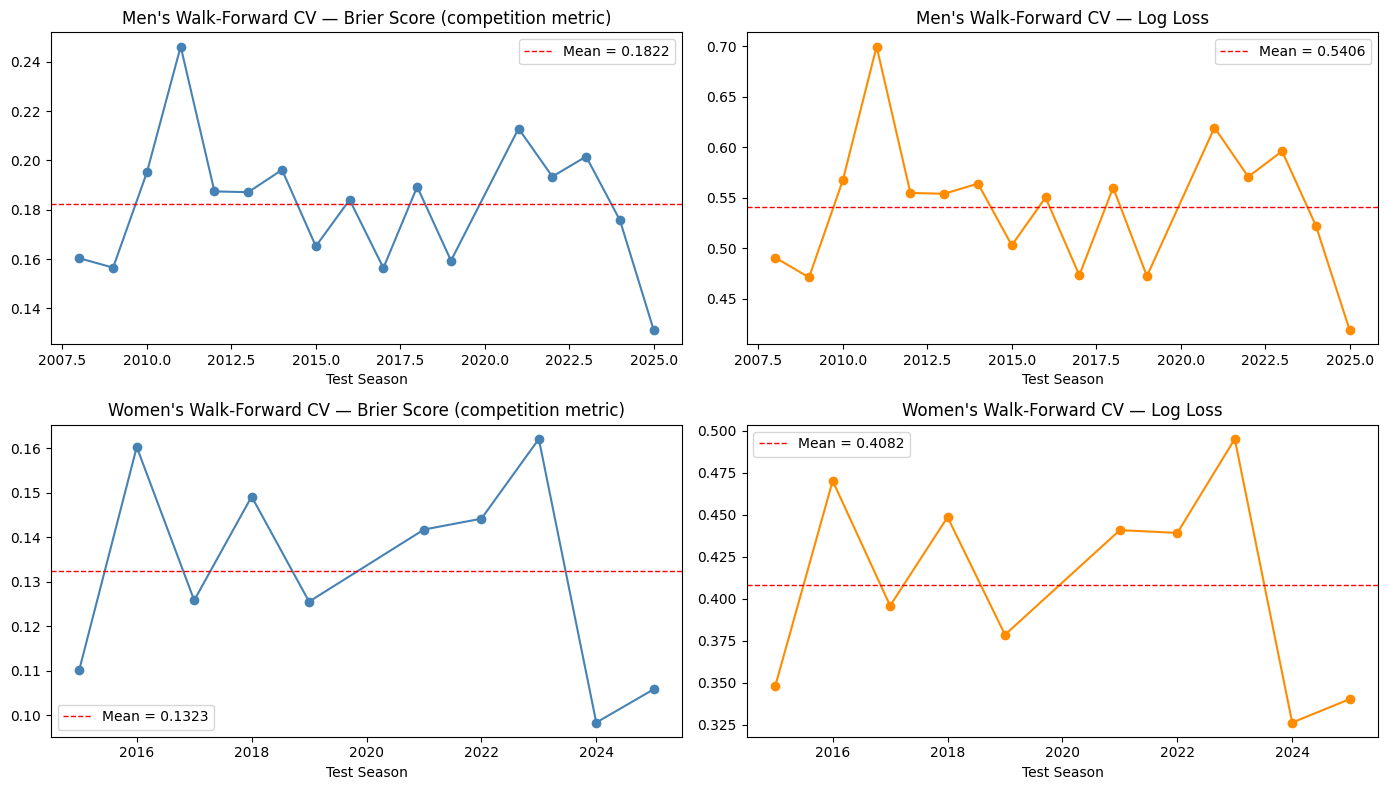

Men's CV:
 test_season  brier_score  log_loss
        2008     0.160320  0.490872
        2009     0.156514  0.471295
        2010     0.195126  0.567471
        2011     0.246165  0.699811
        2012     0.187415  0.554881
        2013     0.187111  0.554049
        2014     0.196156  0.564116
        2015     0.165196  0.503060
        2016     0.184018  0.550424
        2017     0.156387  0.473403
        2018     0.189330  0.560190
        2019     0.159350  0.472498
        2021     0.212901  0.619548
        2022     0.193441  0.570849
        2023     0.201561  0.596216
        2024     0.175746  0.522562
        2025     0.131212  0.419169

Women's CV:
 test_season  brier_score  log_loss
        2015     0.110242  0.347921
        2016     0.160294  0.470115
        2017     0.125826  0.395741
        2018     0.149152  0.448476
        2019     0.125533  0.378471
        2021     0.141739  0.440754
        2022     0.144180  0.439083
        2023     0.162091  0.494983
     

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (results, gender) in enumerate([(cv_results, "Men's"), (w_cv_results, "Women's")]):
    for col_idx, (col, label, color) in enumerate([
        ('brier_score', 'Brier Score (competition metric)', 'steelblue'),
        ('log_loss',    'Log Loss',                         'darkorange'),
    ]):
        ax = axes[row_idx][col_idx]
        ax.plot(results['test_season'], results[col], marker='o', linewidth=1.5, color=color)
        ax.axhline(results[col].mean(), linestyle='--', color='red', linewidth=1,
                   label=f'Mean = {results[col].mean():.4f}')
        ax.set_title(f"{gender} Walk-Forward CV — {label}")
        ax.set_xlabel('Test Season')
        ax.legend()

plt.tight_layout()
plt.show()

print("Men's CV:")
print(cv_results[['test_season', 'brier_score', 'log_loss']].to_string(index=False))
print("\nWomen's CV:")
print(w_cv_results[['test_season', 'brier_score', 'log_loss']].to_string(index=False))

## 7 · Optuna Hyperparameter Tuning

Set `RUN_TUNING = True` in cell 1 to run. Takes ~15-25 minutes but typically improves Brier by 0.002–0.005.

In [13]:
def tune_stacked_ensemble(X_tr, y_tr, w_tr, X_ca, y_ca, n_trials=60):
    """
    Optimize LightGBM + XGB params + LR C + tourney_weight for Brier score.
    w_tr must contain 1.0 (regular) and 2.0 (tourney) — tourney_weight rescales
    the tourney rows so the optimal up-weighting is found automatically.
    """
    w_tr_arr = np.asarray(w_tr)
    is_tourney = w_tr_arr > 1.5  # True for tourney rows

    def objective(trial):
        lgbm_p = dict(
            n_estimators    = trial.suggest_int('lgbm_n', 400, 1200, step=100),
            max_depth       = trial.suggest_int('lgbm_depth', 3, 7),
            num_leaves      = trial.suggest_int('lgbm_leaves', 15, 63),
            learning_rate   = trial.suggest_float('lgbm_lr', 0.01, 0.1, log=True),
            subsample       = trial.suggest_float('lgbm_sub', 0.6, 1.0),
            colsample_bytree= trial.suggest_float('lgbm_col', 0.6, 1.0),
            reg_alpha       = trial.suggest_float('lgbm_alpha', 1e-4, 5.0, log=True),
            reg_lambda      = trial.suggest_float('lgbm_lambda', 1e-4, 10.0, log=True),
            random_state=42, n_jobs=-1, verbose=-1,
        )
        xgb_p = dict(
            n_estimators     = trial.suggest_int('xgb_n', 300, 1000, step=100),
            max_depth        = trial.suggest_int('xgb_depth', 3, 6),
            learning_rate    = trial.suggest_float('xgb_lr', 0.01, 0.1, log=True),
            subsample        = trial.suggest_float('xgb_sub', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('xgb_col', 0.6, 1.0),
            min_child_weight = trial.suggest_int('xgb_mcw', 1, 10),
            reg_alpha        = trial.suggest_float('xgb_alpha', 1e-4, 1.0, log=True),
            reg_lambda       = trial.suggest_float('xgb_lambda', 1e-4, 10.0, log=True),
            eval_metric='logloss', random_state=42, n_jobs=-1,
        )
        lr_C          = trial.suggest_float('lr_C', 0.001, 10.0, log=True)
        tourney_weight = trial.suggest_float('tourney_weight', 1.0, 5.0)

        # Rescale weights: keep regular=1.0, set tourney to suggested value
        w_adjusted = pd.Series(
            np.where(is_tourney, tourney_weight, 1.0).astype('float32'),
            index=w_tr.index,
        )

        ens = train_stacked_ensemble(
            X_tr, y_tr, w_adjusted, X_ca, y_ca,
            lgbm_params=lgbm_p, xgb_params=xgb_p, lr_C=lr_C,
        )
        preds = predict_stacked(ens, X_ca, clip=False)  # no clip during tuning
        return brier_score_loss(y_ca, preds)

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    best = study.best_params
    print(f'Best Brier on calib : {study.best_value:.4f}')
    print(f'Best tourney_weight : {best["tourney_weight"]:.2f}')

    return {
        'lgbm_params': dict(
            n_estimators=best['lgbm_n'], max_depth=best['lgbm_depth'],
            num_leaves=best['lgbm_leaves'], learning_rate=best['lgbm_lr'],
            subsample=best['lgbm_sub'], colsample_bytree=best['lgbm_col'],
            reg_alpha=best['lgbm_alpha'], reg_lambda=best['lgbm_lambda'],
            random_state=42, n_jobs=-1, verbose=-1,
        ),
        'xgb_params': dict(
            n_estimators=best['xgb_n'], max_depth=best['xgb_depth'],
            learning_rate=best['xgb_lr'], subsample=best['xgb_sub'],
            colsample_bytree=best['xgb_col'], min_child_weight=best['xgb_mcw'],
            reg_alpha=best['xgb_alpha'], reg_lambda=best['xgb_lambda'],
            eval_metric='logloss', random_state=42, n_jobs=-1,
        ),
        'lr_C':           best['lr_C'],
        'tourney_weight': best['tourney_weight'],
    }

print('Tuning function defined. RUN_TUNING =', RUN_TUNING)

Tuning function defined. RUN_TUNING = True


## 8 · Train Final Models

In [14]:
def prep_final_splits(train_df, feature_cols, tourney_weight=2.0):
    """Train/calib split — hold out most recent season for calibration."""
    latest = train_df['Season'].max()
    calib_mask = train_df['Season'] == latest
    cols = [c for c in feature_cols if c in train_df.columns]

    X_tr = train_df.loc[~calib_mask, cols].astype('float32')
    y_tr = train_df.loc[~calib_mask, 'target'].astype('int32')
    X_ca = train_df.loc[calib_mask, cols].astype('float32')
    y_ca = train_df.loc[calib_mask, 'target'].astype('int32')

    # Apply tourney_weight (original sample_weight is 1.0 or 2.0)
    raw_w = train_df.loc[~calib_mask, 'sample_weight']
    w_tr  = pd.Series(
        np.where(raw_w > 1.5, tourney_weight, 1.0).astype('float32'),
        index=raw_w.index,
    )

    fill = X_tr.median().fillna(0.0)
    return X_tr.fillna(fill), y_tr, w_tr, X_ca.fillna(fill), y_ca, cols


# ── Optional tuning (finds best params + tourney_weight) ──────────────────────
if RUN_TUNING:
    _tmp_X_tr, _tmp_y_tr, _tmp_w_tr, _tmp_X_ca, _tmp_y_ca, _ = prep_final_splits(m_train, ADVANCED_FEATURE_COLS)
    print("Tuning men's model...")
    m_best = tune_stacked_ensemble(_tmp_X_tr, _tmp_y_tr, _tmp_w_tr, _tmp_X_ca, _tmp_y_ca, n_trials=60)

    _tmp_X_tr, _tmp_y_tr, _tmp_w_tr, _tmp_X_ca, _tmp_y_ca, _ = prep_final_splits(w_train, ADVANCED_FEATURE_COLS)
    print("Tuning women's model...")
    w_best = tune_stacked_ensemble(_tmp_X_tr, _tmp_y_tr, _tmp_w_tr, _tmp_X_ca, _tmp_y_ca, n_trials=60)
else:
    m_best = w_best = {}

# ── Build final splits with best tourney_weight ────────────────────────────────
m_tw = m_best.get('tourney_weight', 2.0)
w_tw = w_best.get('tourney_weight', 2.0)

X_tr_m, y_tr_m, w_tr_m, X_ca_m, y_ca_m, m_cols = prep_final_splits(m_train, ADVANCED_FEATURE_COLS, tourney_weight=m_tw)
X_tr_w, y_tr_w, w_tr_w, X_ca_w, y_ca_w, w_cols = prep_final_splits(w_train, ADVANCED_FEATURE_COLS, tourney_weight=w_tw)

print(f"Men's   train: {len(X_tr_m):,}  calib: {len(X_ca_m):,}  features: {len(m_cols)}  tourney_weight: {m_tw:.2f}")
print(f"Women's train: {len(X_tr_w):,}  calib: {len(X_ca_w):,}  features: {len(w_cols)}  tourney_weight: {w_tw:.2f}")

# ── Train final ensembles ─────────────────────────────────────────────────────
# Strip tourney_weight from m_best/w_best before passing to train_stacked_ensemble
m_ens_params = {k: v for k, v in m_best.items() if k != 'tourney_weight'}
w_ens_params = {k: v for k, v in w_best.items() if k != 'tourney_weight'}

print("\nTraining men's stacked ensemble...")
m_ensemble = train_stacked_ensemble(X_tr_m, y_tr_m, w_tr_m, X_ca_m, y_ca_m, **m_ens_params)

print("Training women's stacked ensemble...")
w_ensemble = train_stacked_ensemble(X_tr_w, y_tr_w, w_tr_w, X_ca_w, y_ca_w, **w_ens_params)

print('\nDone.')

Tuning men's model...


Best trial: 0. Best value: 0.161625:   2%|▏         | 1/60 [00:12<12:07, 12.33s/it]

  Meta weights → LGBM: 1.597  XGB: 2.795  LR: 1.043


Best trial: 1. Best value: 0.161416:   3%|▎         | 2/60 [00:22<10:56, 11.32s/it]

  Meta weights → LGBM: 2.208  XGB: 2.094  LR: 1.148


...

Best trial: 8. Best value: 0.131061:  98%|█████████▊| 59/60 [06:32<00:06,  6.62s/it]

  Meta weights → LGBM: 1.786  XGB: 1.584  LR: 2.482


Best trial: 8. Best value: 0.131061: 100%|██████████| 60/60 [06:39<00:00,  6.66s/it]

  Meta weights → LGBM: 2.112  XGB: 1.032  LR: 2.699
Best Brier on calib : 0.1311
Best tourney_weight : 2.24


Men's   train: 240,662  calib: 11,294  features: 50  tourney_weight: 2.58
Women's train: 165,338  calib: 10,958  features: 37  tourney_weight: 2.24

Training men's stacked ensemble...
  Meta weights → LGBM: 2.144  XGB: 2.316  LR: 0.992
Training women's stacked ensemble...
  Meta weights → LGBM: 1.935  XGB: 1.955  LR: 1.956

Done.


## 9 · Feature Importance

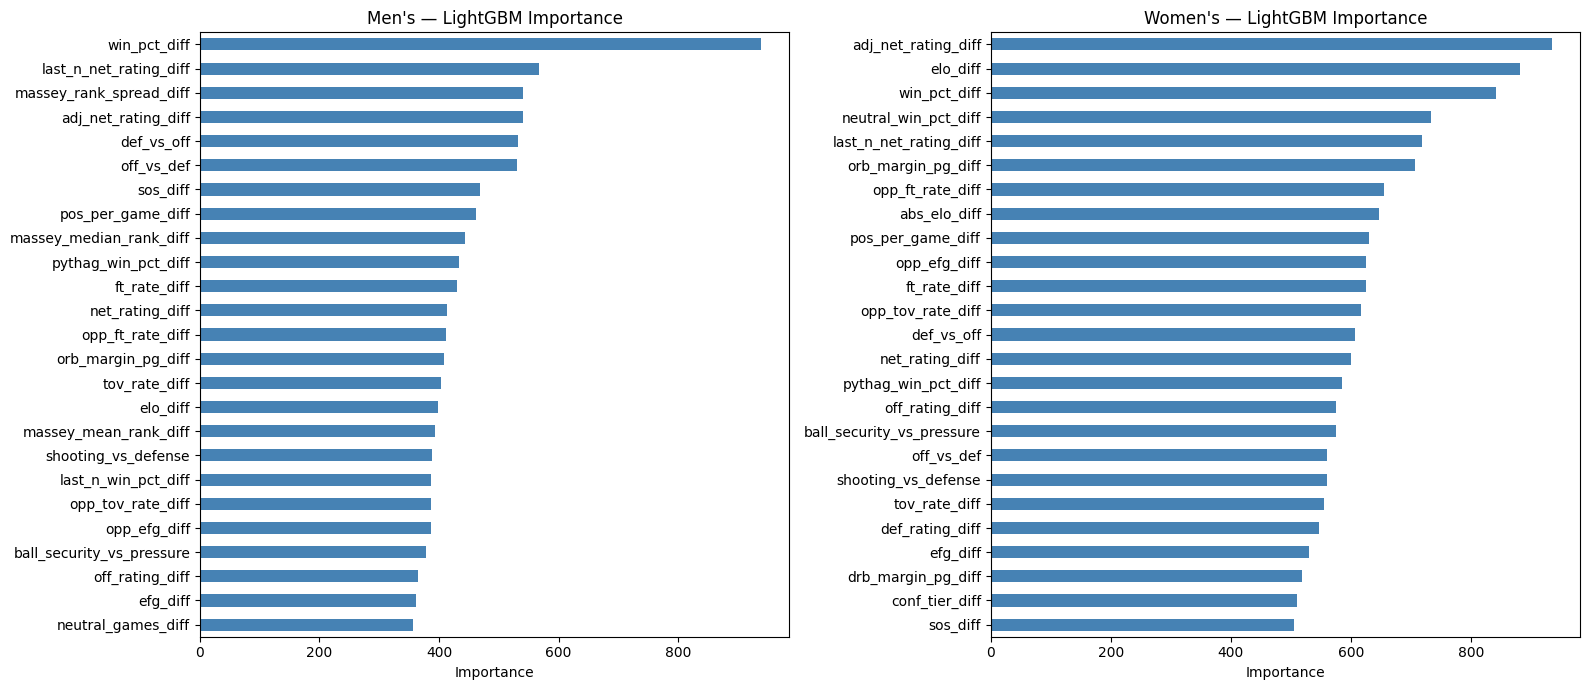

Top 15 men's features:
win_pct_diff               939
last_n_net_rating_diff     568
massey_rank_spread_diff    540
adj_net_rating_diff        540
def_vs_off                 532
off_vs_def                 530
sos_diff                   469
pos_per_game_diff          462
massey_median_rank_diff    444
pythag_win_pct_diff        433
ft_rate_diff               430
net_rating_diff            413
opp_ft_rate_diff           412
orb_margin_pg_diff         408
tov_rate_diff              403


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, ens, cols, label in [
    (axes[0], m_ensemble, m_cols, "Men's — LightGBM Importance"),
    (axes[1], w_ensemble, w_cols, "Women's — LightGBM Importance"),
]:
    lgbm_model = ens['lgbm_cal'].calibrated_classifiers_[0].estimator
    importances = pd.Series(
        lgbm_model.feature_importances_, index=cols
    ).sort_values(ascending=False)

    importances.head(25).sort_values().plot.barh(ax=ax, color='steelblue')
    ax.set_title(label)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

print('Top 15 men\'s features:')
lgbm_m = m_ensemble['lgbm_cal'].calibrated_classifiers_[0].estimator
print(pd.Series(lgbm_m.feature_importances_, index=m_cols)
      .sort_values(ascending=False).head(15).to_string())

In [16]:
## 9b · Seed-Diff Blend Model
#
# A simple LR on seed_diff alone is a strong, well-calibrated baseline.
# Blending 15% of it into the advanced model's predictions reduces overconfidence
# on matchups where seeds strongly disagree with the model's feature-based pick.
# For matchups with no seed info (non-tournament teams), it returns 0.5 (no effect).

SEED_BLEND_WEIGHT = 0.15   # 15% seed model, 85% advanced model

def train_seed_model(tourney_matchups):
    """Train LR on seed_diff using all historical tourney games."""
    df = tourney_matchups.dropna(subset=['seed_diff', 'target']).copy()
    X = df[['seed_diff']].astype('float32')
    y = df['target'].astype('int32')
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X)
    lr = LogisticRegression(C=1.0, max_iter=1000, random_state=42)
    lr.fit(X_sc, y)
    return {'model': lr, 'scaler': scaler}


def apply_seed_blend(advanced_preds, matchup_df, seed_model, blend_weight=SEED_BLEND_WEIGHT):
    """
    Blend advanced predictions with seed-based predictions.
    Returns 0.5 for matchups with no seed info (no effect on non-tourney pairs).
    """
    seed_preds = np.full(len(matchup_df), 0.5)
    has_seed = matchup_df['seed_diff'].notna()
    if has_seed.any():
        X = matchup_df.loc[has_seed, ['seed_diff']].astype('float32')
        X_sc = seed_model['scaler'].transform(X)
        seed_preds[has_seed.values] = seed_model['model'].predict_proba(X_sc)[:, 1]
    return (1 - blend_weight) * advanced_preds + blend_weight * seed_preds


# Train seed models on all historical tourney matchups
m_seed_model = train_seed_model(m_trn_matchups)
w_seed_model = train_seed_model(w_trn_matchups)
print(f'Seed models trained.')
print(f"Men's   seed model coef (seed_diff): {m_seed_model['model'].coef_[0][0]:.4f}")
print(f"Women's seed model coef (seed_diff): {w_seed_model['model'].coef_[0][0]:.4f}")

Seed models trained.
Men's   seed model coef (seed_diff): -1.1959
Women's seed model coef (seed_diff): -2.0009


## 10 · Generate 2026 Submission

In [17]:
def predict_for_submission(sample_sub_df, team_features, ensemble, feature_cols,
                           seed_model=None):
    """Generate predictions for submission IDs using the stacked ensemble,
    optionally blended with a seed-diff model."""
    from pipeline import _parse_submission_ids

    fake_games = _parse_submission_ids(sample_sub_df)
    matchups   = build_advanced_matchup_dataset(fake_games, team_features)
    sub_feats  = matchups[matchups['target'] == 1].reset_index(drop=True)

    avail = [c for c in feature_cols if c in sub_feats.columns]
    X_sub = sub_feats[avail].astype('float32').fillna(0.0)

    X_aligned = pd.DataFrame(0.0, index=X_sub.index, columns=ensemble['feature_names'])
    for col in avail:
        if col in X_aligned.columns:
            X_aligned[col] = X_sub[col].values

    preds = predict_stacked(ensemble, X_aligned)   # already clipped [0.05, 0.95]

    if seed_model is not None:
        preds = apply_seed_blend(preds, sub_feats, seed_model)
        preds = np.clip(preds, 0.05, 0.95)         # re-clip after blend

    result = sample_sub_df[['ID']].copy()
    result['Pred'] = preds
    return result


sub_2026   = sample_sub[sample_sub['ID'].str.contains('2026')].reset_index(drop=True)
low_tid    = sub_2026['ID'].str.split('_').str[1].astype(int)
mens_sub   = sub_2026[low_tid.between(1000, 1999)].reset_index(drop=True)
womens_sub = sub_2026[low_tid.between(3000, 3999)].reset_index(drop=True)

print(f"Men's 2026 matchups   : {len(mens_sub):,}")
print(f"Women's 2026 matchups : {len(womens_sub):,}")

print('Predicting men\'s...')
m_preds = predict_for_submission(mens_sub,   m_team_features, m_ensemble, m_cols, seed_model=m_seed_model)

print('Predicting women\'s...')
w_preds = predict_for_submission(womens_sub, w_team_features, w_ensemble, w_cols, seed_model=w_seed_model)

submission = pd.concat([m_preds, w_preds], ignore_index=True)

print(f'\nTotal rows : {len(submission):,}')
print(f'Pred range : [{submission["Pred"].min():.4f}, {submission["Pred"].max():.4f}]')
print(f'Pred mean  : {submission["Pred"].mean():.4f}  (should be ~0.500)')
print(f'Pred std   : {submission["Pred"].std():.4f}')
submission.head(10)

Men's 2026 matchups   : 66,430
Women's 2026 matchups : 65,703
Predicting men's...
Predicting women's...

Total rows : 132,133
Pred range : [0.0500, 0.9500]
Pred mean  : 0.4978  (should be ~0.500)
Pred std   : 0.3052


,ID,Pred
0,2026_1101_1102,0.789375
1,2026_1101_1103,0.140608
2,2026_1101_1104,0.127661
3,2026_1101_1105,0.659909
4,2026_1101_1106,0.777345
5,2026_1101_1107,0.774269
6,2026_1101_1108,0.784613
7,2026_1101_1110,0.510096
8,2026_1101_1111,0.369677
9,2026_1101_1112,0.127266


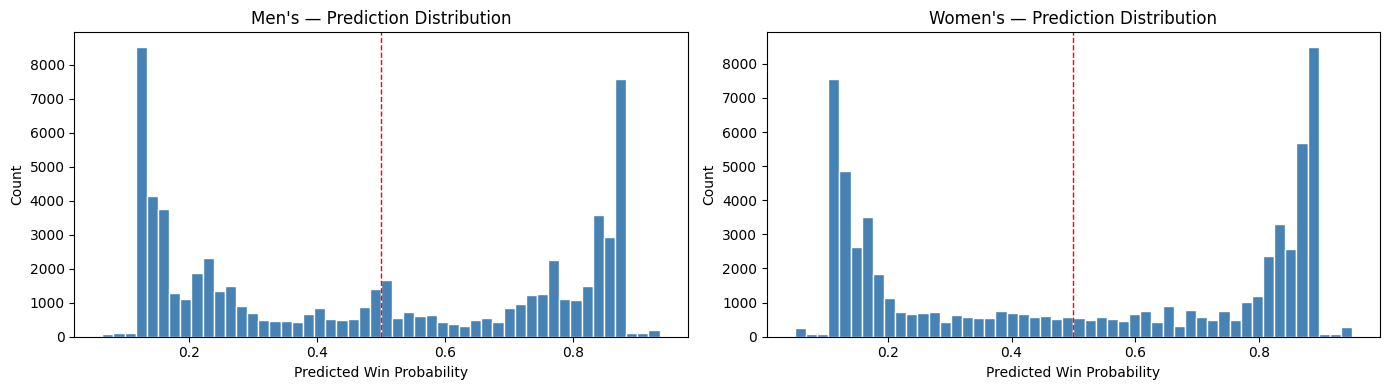

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, preds, label in [
    (axes[0], m_preds['Pred'], "Men's"),
    (axes[1], w_preds['Pred'], "Women's"),
]:
    ax.hist(preds, bins=50, edgecolor='white', color='steelblue')
    ax.axvline(0.5, linestyle='--', color='red', linewidth=1)
    ax.set_title(f'{label} — Prediction Distribution')
    ax.set_xlabel('Predicted Win Probability')
    ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

In [19]:
os.makedirs(OUT, exist_ok=True)
out_path = os.path.join(OUT, 'submission_advanced_2026.csv')
submission.to_csv(out_path, index=False)
print(f'Saved → {out_path}')

# ── CV Brier Score Summary ────────────────────────────────────────────────────
for label, results in [("MEN'S", cv_results), ("WOMEN'S", w_cv_results)]:
    print('\n' + '='*49)
    print(f"  ADVANCED MODEL — {label} CV Brier Score Summary")
    print('='*49)
    bs = results['brier_score']
    print(f'  Mean  : {bs.mean():.4f}  ← competition metric')
    print(f'  Std   : {bs.std():.4f}')
    print(f'  Best  : {bs.min():.4f}  (season {results.loc[bs.idxmin(), "test_season"]})')
    print(f'  Worst : {bs.max():.4f}  (season {results.loc[bs.idxmax(), "test_season"]})')
    print('='*49)

Saved → ../submissions/submission_advanced_2026.csv

  ADVANCED MODEL — MEN'S CV Brier Score Summary
  Mean  : 0.1822  ← competition metric
  Std   : 0.0265
  Best  : 0.1312  (season 2025)
  Worst : 0.2462  (season 2011)

  ADVANCED MODEL — WOMEN'S CV Brier Score Summary
  Mean  : 0.1323  ← competition metric
  Std   : 0.0226
  Best  : 0.0984  (season 2024)
  Worst : 0.1621  (season 2023)


In [20]:
submission.shape

(132133, 2)